# Notebook — Teste do módulo `reference_frames.py`

Este notebook testa o módulo:

```python
geodesy/reference_frames.py
```

Serão testadas rotações nos eixos X, Y e Z, matriz de pequenos ângulos, transformação de Helmert de 7 parâmetros, transformação inversa aproximada e conversão de segundos de arco para radianos.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")

import geodesy
from geodesy import reference_frames
from geodesy import coordinates

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Matrizes de rotação nos eixos X, Y e Z


In [2]:
# ============================================================
# 1. MATRIZES DE ROTAÇÃO
# ============================================================

angle_deg = 30.0
angle_rad = np.deg2rad(angle_deg)

Rx = reference_frames.rotation_matrix_x(angle_rad)
Ry = reference_frames.rotation_matrix_y(angle_rad)
Rz = reference_frames.rotation_matrix_z(angle_rad)

print("Rx:")
print(Rx)

print("\nRy:")
print(Ry)

print("\nRz:")
print(Rz)

print("\nTeste Rx @ Rx.T:")
print(Rx @ Rx.T)


Rx:
[[ 1.         0.         0.       ]
 [ 0.         0.8660254 -0.5      ]
 [ 0.         0.5        0.8660254]]

Ry:
[[ 0.8660254  0.         0.5      ]
 [ 0.         1.         0.       ]
 [-0.5        0.         0.8660254]]

Rz:
[[ 0.8660254 -0.5        0.       ]
 [ 0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]

Teste Rx @ Rx.T:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -7.43708407e-18]
 [ 0.00000000e+00 -7.43708407e-18  1.00000000e+00]]


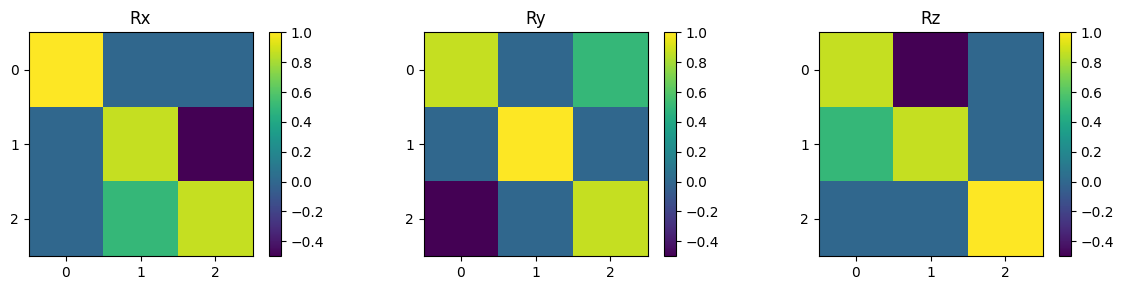

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, R, title in zip(axes, [Rx, Ry, Rz], ["Rx", "Ry", "Rz"]):
    im = ax.imshow(R)
    ax.set_title(title)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


## 2. Rotação de um vetor unitário


In [4]:
# ============================================================
# 2. ROTAÇÃO DE VETORES
# ============================================================

v = np.array([[1.0], [0.0], [0.0]])

vx = Rx @ v
vy = Ry @ v
vz = Rz @ v

print("Vetor original:")
print(v.ravel())

print("\nRotacionado por Rx:")
print(vx.ravel())

print("\nRotacionado por Ry:")
print(vy.ravel())

print("\nRotacionado por Rz:")
print(vz.ravel())


Vetor original:
[1. 0. 0.]

Rotacionado por Rx:
[1. 0. 0.]

Rotacionado por Ry:
[ 0.8660254  0.        -0.5      ]

Rotacionado por Rz:
[0.8660254 0.5       0.       ]


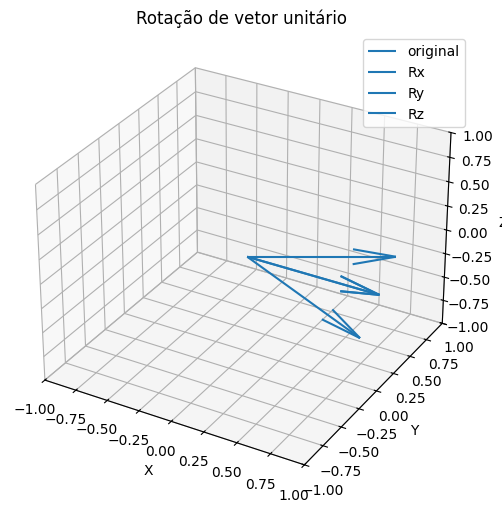

In [5]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

vectors = {
    "original": v.ravel(),
    "Rx": vx.ravel(),
    "Ry": vy.ravel(),
    "Rz": vz.ravel()
}

for name, vec in vectors.items():
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], length=1.0, normalize=True, label=name)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Rotação de vetor unitário")
ax.legend()
plt.show()


## 3. Conversão de segundos de arco para radianos


Segundos de arco:
[ 0.1  0.5  1.  10.  60. ]

Radianos:
[4.84813681e-07 2.42406841e-06 4.84813681e-06 4.84813681e-05
 2.90888209e-04]


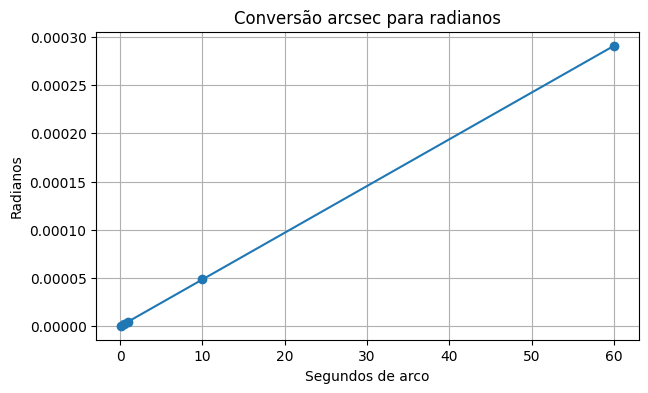

In [6]:
# ============================================================
# 3. ARCSEC -> RAD
# ============================================================

arcsec_values = np.array([0.1, 0.5, 1.0, 10.0, 60.0])
rad_values = reference_frames.arcsec_to_rad(arcsec_values)

print("Segundos de arco:")
print(arcsec_values)

print("\nRadianos:")
print(rad_values)

plt.figure(figsize=(7, 4))
plt.plot(arcsec_values, rad_values, marker="o")
plt.xlabel("Segundos de arco")
plt.ylabel("Radianos")
plt.title("Conversão arcsec para radianos")
plt.grid(True)
plt.show()


## 4. Matriz de pequenos ângulos


In [7]:
# ============================================================
# 4. MATRIZ DE PEQUENOS ÂNGULOS
# ============================================================

rx = reference_frames.arcsec_to_rad(0.5)
ry = reference_frames.arcsec_to_rad(-0.3)
rz = reference_frames.arcsec_to_rad(1.2)

Rsmall = reference_frames.small_angle_rotation_matrix(rx, ry, rz)

print("rx, ry, rz em rad:")
print(rx, ry, rz)

print("\nMatriz de pequenos ângulos:")
print(Rsmall)

print("\nTeste Rsmall @ Rsmall.T:")
print(Rsmall @ Rsmall.T)


rx, ry, rz em rad:
2.42406840554768e-06 -1.4544410433286078e-06 5.817764173314431e-06

Matriz de pequenos ângulos:
[[ 1.00000000e+00 -5.81776417e-06 -1.45444104e-06]
 [ 5.81776417e-06  1.00000000e+00 -2.42406841e-06]
 [ 1.45444104e-06  2.42406841e-06  1.00000000e+00]]

Teste Rsmall @ Rsmall.T:
[[ 1.00000000e+00  3.52566458e-12 -1.41026583e-11]
 [ 3.52566458e-12  1.00000000e+00  8.46159499e-12]
 [-1.41026583e-11  8.46159499e-12  1.00000000e+00]]


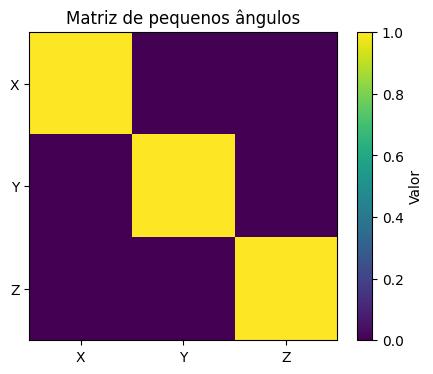

In [8]:
plt.figure(figsize=(5, 4))
plt.imshow(Rsmall)
plt.colorbar(label="Valor")
plt.title("Matriz de pequenos ângulos")
plt.xticks([0, 1, 2], ["X", "Y", "Z"])
plt.yticks([0, 1, 2], ["X", "Y", "Z"])
plt.show()


## 5. Transformação de Helmert de 7 parâmetros


In [9]:
# ============================================================
# 5. TRANSFORMAÇÃO DE HELMERT
# ============================================================

# Pontos simulados em ECEF
lat = np.array([-3.2, -3.1, -3.3, -3.25])
lon = np.array([-52.2, -52.1, -52.3, -52.25])
h = np.array([100, 200, 150, 120], dtype=float)

X, Y, Z = coordinates.geodetic_to_ecef(lat, lon, h)

# Parâmetros fictícios de transformação
tx, ty, tz = 0.5, -1.0, 0.8
rx = reference_frames.arcsec_to_rad(0.2)
ry = reference_frames.arcsec_to_rad(-0.1)
rz = reference_frames.arcsec_to_rad(0.3)
scale_ppm = 0.5

X2, Y2, Z2 = reference_frames.helmert_transform_7params(
    X, Y, Z,
    tx=tx, ty=ty, tz=tz,
    rx=rx, ry=ry, rz=rz,
    scale_ppm=scale_ppm
)

print("Coordenadas originais:")
for i in range(len(X)):
    print(i, X[i], Y[i], Z[i])

print("\nCoordenadas transformadas:")
for i in range(len(X2)):
    print(i, X2[i], Y2[i], Z2[i])

dX = X2 - X
dY = Y2 - Y
dZ = Z2 - Z

print("\nDiferenças:")
print("dX:", dX)
print("dY:", dY)
print("dZ:", dZ)


Coordenadas originais:
0 3903211.688895016 -5031990.188336126 -353663.02885195264
1 3912422.8193494426 -5025728.406602428 -342627.2081796491
2 3894070.4241602933 -5038338.382701833 -364706.0798345489
3 3898640.761234085 -5035164.315367076 -359184.38313015294

Coordenadas transformadas:
0 3903221.63069834 -5031987.684415579 -353665.39250990655
1 3912432.7513006157 -5025725.896854577 -342629.5557824104
2 3894080.375979889 -5038335.884543171 -364708.45960122667
3 3898650.708045358 -5035161.814328082 -359186.75484255527

Diferenças:
dX: [9.94180332 9.93195117 9.9518196  9.94681127]
dY: [2.50392055 2.50974785 2.49815866 2.50103899]
dZ: [-2.36365795 -2.34760276 -2.37976668 -2.3717124 ]


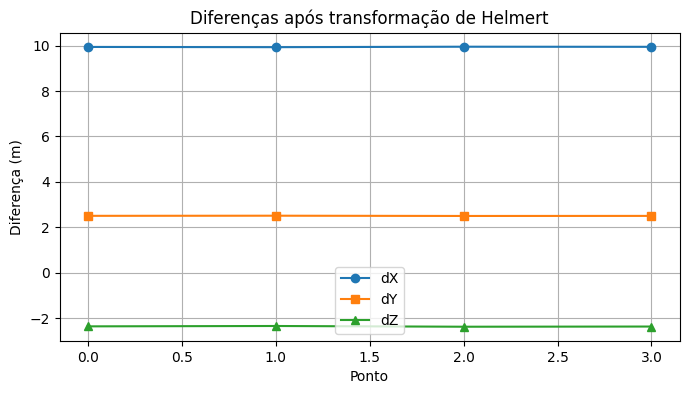

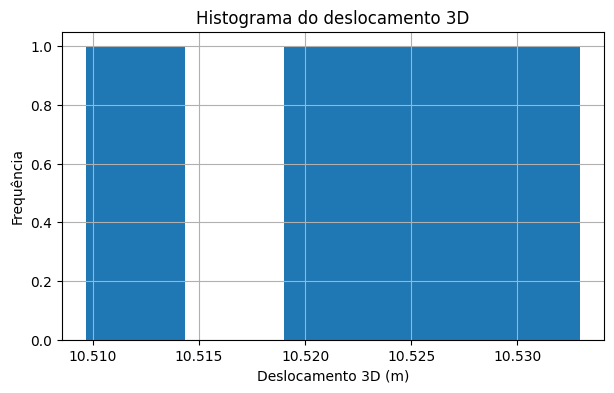

In [10]:
# Visualização das diferenças da transformação

indices = np.arange(len(X))

plt.figure(figsize=(8, 4))
plt.plot(indices, dX, marker="o", label="dX")
plt.plot(indices, dY, marker="s", label="dY")
plt.plot(indices, dZ, marker="^", label="dZ")
plt.xlabel("Ponto")
plt.ylabel("Diferença (m)")
plt.title("Diferenças após transformação de Helmert")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(np.sqrt(dX**2 + dY**2 + dZ**2), bins=5)
plt.xlabel("Deslocamento 3D (m)")
plt.ylabel("Frequência")
plt.title("Histograma do deslocamento 3D")
plt.grid(True)
plt.show()


## 6. Transformação inversa aproximada


In [11]:
# ============================================================
# 6. TRANSFORMAÇÃO INVERSA APROXIMADA
# ============================================================

X_back, Y_back, Z_back = reference_frames.inverse_helmert_transform_7params(
    X2, Y2, Z2,
    tx=tx, ty=ty, tz=tz,
    rx=rx, ry=ry, rz=rz,
    scale_ppm=scale_ppm
)

err = np.sqrt((X_back-X)**2 + (Y_back-Y)**2 + (Z_back-Z)**2)

print("Erro de retorno aproximado por ponto:")
print(err)

print("Erro máximo:", np.max(err), "m")
print("Erro médio:", np.mean(err), "m")


Erro de retorno aproximado por ponto:
[1.58338922e-05 1.58132709e-05 1.58560676e-05 1.58453120e-05]
Erro máximo: 1.5856067632059402e-05 m
Erro médio: 1.5837135670126905e-05 m


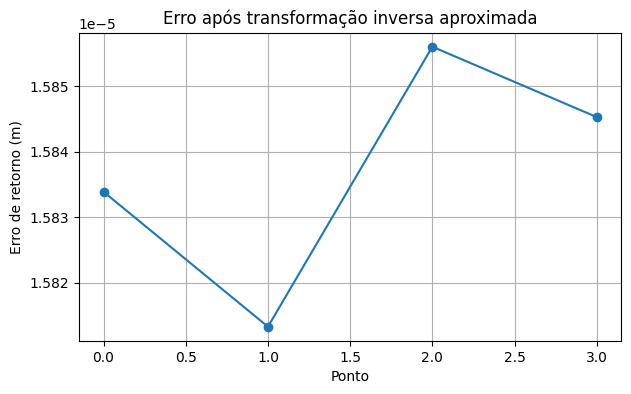

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(indices, err, marker="o")
plt.xlabel("Ponto")
plt.ylabel("Erro de retorno (m)")
plt.title("Erro após transformação inversa aproximada")
plt.grid(True)
plt.show()


## 7. Função `apply_rotation`


x original: [1. 2. 3. 4.]
y original: [0. 0. 0. 0.]

x rotacionado: [0.70710678 1.41421356 2.12132034 2.82842712]
y rotacionado: [0.70710678 1.41421356 2.12132034 2.82842712]


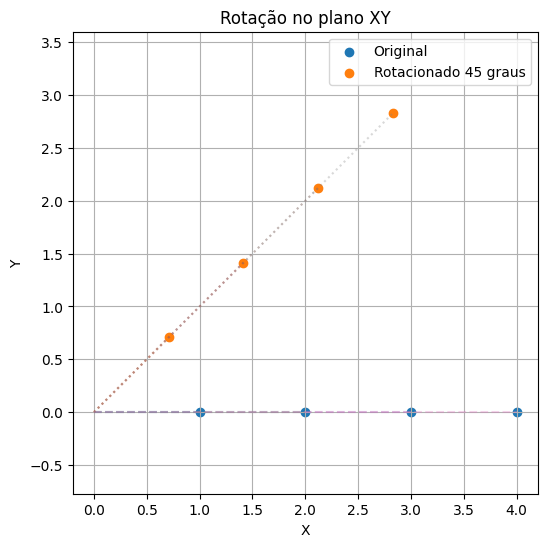

In [13]:
# ============================================================
# 7. APLICAÇÃO DE ROTAÇÃO
# ============================================================

Rz45 = reference_frames.rotation_matrix_z(np.deg2rad(45))

x = np.array([1, 2, 3, 4], dtype=float)
y = np.zeros_like(x)
z = np.zeros_like(x)

xr, yr, zr = reference_frames.apply_rotation(x, y, z, Rz45)

print("x original:", x)
print("y original:", y)
print("\nx rotacionado:", xr)
print("y rotacionado:", yr)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, label="Original")
plt.scatter(xr, yr, label="Rotacionado 45 graus")
for i in range(len(x)):
    plt.plot([0, x[i]], [0, y[i]], linestyle="--", alpha=0.3)
    plt.plot([0, xr[i]], [0, yr[i]], linestyle=":", alpha=0.3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Rotação no plano XY")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()


## 8. Efeito da escala na transformação


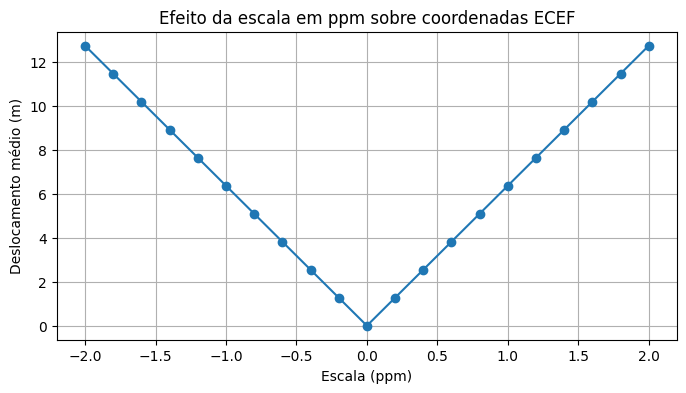

In [14]:
# ============================================================
# 8. EFEITO DA ESCALA
# ============================================================

scales = np.linspace(-2, 2, 21)
mean_displacements = []

for sc in scales:
    Xs, Ys, Zs = reference_frames.helmert_transform_7params(
        X, Y, Z,
        tx=0, ty=0, tz=0,
        rx=0, ry=0, rz=0,
        scale_ppm=sc
    )
    disp = np.sqrt((Xs-X)**2 + (Ys-Y)**2 + (Zs-Z)**2)
    mean_displacements.append(np.mean(disp))

plt.figure(figsize=(8, 4))
plt.plot(scales, mean_displacements, marker="o")
plt.xlabel("Escala (ppm)")
plt.ylabel("Deslocamento médio (m)")
plt.title("Efeito da escala em ppm sobre coordenadas ECEF")
plt.grid(True)
plt.show()


## 9. Contorno didático de deslocamento por escala


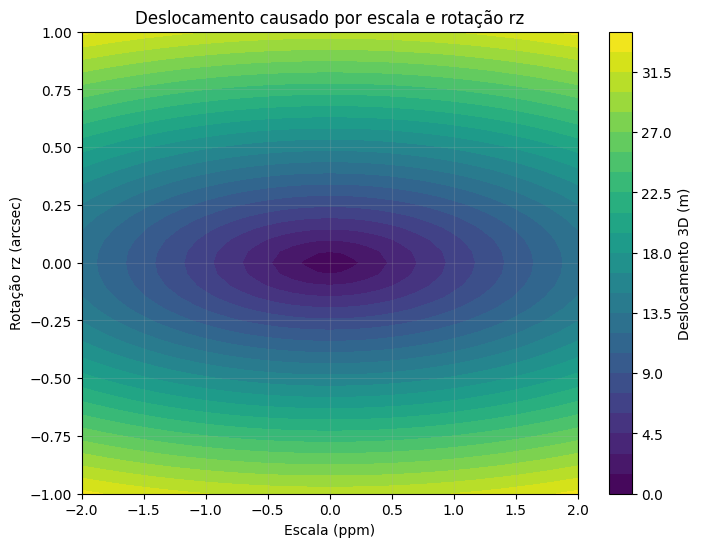

In [15]:
# ============================================================
# 9. CONTOURF DO DESLOCAMENTO POR ESCALA E ROTAÇÃO
# ============================================================

scale_grid = np.linspace(-2, 2, 41)
rz_grid_arcsec = np.linspace(-1, 1, 41)

SCALE, RZARC = np.meshgrid(scale_grid, rz_grid_arcsec)
DISP = np.zeros_like(SCALE)

# Usa um único ponto ECEF como teste
X0, Y0, Z0 = X[0], Y[0], Z[0]

for i in range(SCALE.shape[0]):
    for j in range(SCALE.shape[1]):
        Xtmp, Ytmp, Ztmp = reference_frames.helmert_transform_7params(
            X0, Y0, Z0,
            tx=0, ty=0, tz=0,
            rx=0, ry=0,
            rz=reference_frames.arcsec_to_rad(RZARC[i, j]),
            scale_ppm=SCALE[i, j]
        )
        DISP[i, j] = np.sqrt((Xtmp-X0)**2 + (Ytmp-Y0)**2 + (Ztmp-Z0)**2)

plt.figure(figsize=(8, 6))
c = plt.contourf(SCALE, RZARC, DISP, levels=30)
plt.colorbar(c, label="Deslocamento 3D (m)")
plt.xlabel("Escala (ppm)")
plt.ylabel("Rotação rz (arcsec)")
plt.title("Deslocamento causado por escala e rotação rz")
plt.grid(alpha=0.2)
plt.show()


## 10. Resumo final


Se todas as células foram executadas sem erro, o módulo `reference_frames.py` está funcionando corretamente.

Os próximos notebooks podem testar:

```python
geodesy/time_systems.py
geodesy/normal_gravity.py
```
